# Topic Modeling with TF-IDF
This notebook demonstrates topic modeling on text data using Latent Dirichlet Allocation (LDA). The workflow includes data preprocessing, text cleaning, and applying LDA to discover underlying topics in the dataset.

**Summary of Libraries:**  
- `pandas` (data handling)  
- `nltk`, `spacy`, `re` (text preprocessing)  
- `scikit-learn` (vectorization, modeling)  
- `gensim` (LDA)  
- `matplotlib`, `seaborn`, `pyLDAvis` (visualization)

In [8]:
import pandas as pd
import nltk
import re
import spacy
import matplotlib.pyplot as plt


from nltk.sentiment.vader import SentimentIntensityAnalyzer 
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.decomposition import NMF

# 1. Data Collection
- Load the mabel file using python read csv
- Header = None tells pandas that the text file does not have header row
- specify the character encoding
- skip the lines in the mabel.txt if the strucuture is different for any of the row

In [9]:
df = pd.read_csv("mabel.txt", header=None, encoding='utf8', on_bad_lines='skip')

In [10]:
df

,0,1
0,05/12/19,1:42 pm - Messages to this chat and calls are...
1,05/12/19,1:42 pm - Mabel Infoziant: Hi this is Mabel w...
2,05/12/19,1:42 pm - Mabel Infoziant: What’s your full name
3,05/12/19,1:42 pm - AR❤: Ramisha Rani K
4,05/12/19,1:42 pm - Mabel Infoziant: Ok
5,05/12/19,1:42 pm - Mabel Infoziant: ramisharanik@gmail...
6,05/12/19,1:43 pm - Mabel Infoziant: Your email Id?
7,05/12/19,1:43 pm - AR❤: Yes Mam
8,05/12/19,1:43 pm - Mabel Infoziant: I will send 2 abst...
9,05/12/19,1:43 pm - AR❤: Yeah mam


## 2. Data Preprocessing
- Drop the first numerical colmn as it does not hold any valuable information 
- Name the columns into Date and chat
- Extract the chat column using python spilit function with - 
- Rearrage the data frame with Date, Time, Name, Chat

In [11]:
df=df.drop(0)
df.columns=['Date','Chat']
Message=df["Chat"].str.split("-",n=1,expand=True)
df["Time"]=Message[0]
Message1=Message[1].str.split(":",n=1,expand=True)
df["Name"]=Message1[0]
df["Chat"]=Message1[1]
df=df[["Date","Time","Name","Chat"]]
df

,Date,Time,Name,Chat
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K
4,05/12/19,1:42 pm,Mabel Infoziant,Ok
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com
6,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?
7,05/12/19,1:43 pm,AR❤,Yes Mam
8,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working
9,05/12/19,1:43 pm,AR❤,Yeah mam
10,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too


In [12]:
dataset=df
dataset.dropna(inplace=True)
nltk.download('vader_lexicon') # Download VADER lexicon for sentiment analysisß
print(dataset)

        Date        Time              Name  \
1   05/12/19    1:42 pm    Mabel Infoziant   
2   05/12/19    1:42 pm    Mabel Infoziant   
3   05/12/19    1:42 pm                AR❤   
4   05/12/19    1:42 pm    Mabel Infoziant   
5   05/12/19    1:42 pm    Mabel Infoziant   
6   05/12/19    1:43 pm    Mabel Infoziant   
7   05/12/19    1:43 pm                AR❤   
8   05/12/19    1:43 pm    Mabel Infoziant   
9   05/12/19    1:43 pm                AR❤   
10  05/12/19    1:43 pm    Mabel Infoziant   
11  05/12/19    1:43 pm    Mabel Infoziant   
12  05/12/19    1:44 pm                AR❤   
13  05/12/19    1:45 pm                AR❤   
14  05/12/19    1:48 pm    Mabel Infoziant   
15  05/12/19    1:48 pm    Mabel Infoziant   
16  05/12/19    1:49 pm                AR❤   
17  05/12/19    2:00 pm                AR❤   
18  05/12/19    2:04 pm    Mabel Infoziant   
19  05/12/19    2:04 pm    Mabel Infoziant   
20  05/12/19    2:06 pm                AR❤   
21  05/12/19    2:07 pm           

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/madhusudhananjeyaram/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## Prepare the data set for analysis

- download the vader lxicon libary to do the sentiment analysis using NLTK

In [13]:
dataset.dropna(inplace=True)
nltk.download('vader_lexicon') # Download VADER lexicon for sentiment analysisß
print(dataset)

        Date        Time              Name  \
1   05/12/19    1:42 pm    Mabel Infoziant   
2   05/12/19    1:42 pm    Mabel Infoziant   
3   05/12/19    1:42 pm                AR❤   
4   05/12/19    1:42 pm    Mabel Infoziant   
5   05/12/19    1:42 pm    Mabel Infoziant   
6   05/12/19    1:43 pm    Mabel Infoziant   
7   05/12/19    1:43 pm                AR❤   
8   05/12/19    1:43 pm    Mabel Infoziant   
9   05/12/19    1:43 pm                AR❤   
10  05/12/19    1:43 pm    Mabel Infoziant   
11  05/12/19    1:43 pm    Mabel Infoziant   
12  05/12/19    1:44 pm                AR❤   
13  05/12/19    1:45 pm                AR❤   
14  05/12/19    1:48 pm    Mabel Infoziant   
15  05/12/19    1:48 pm    Mabel Infoziant   
16  05/12/19    1:49 pm                AR❤   
17  05/12/19    2:00 pm                AR❤   
18  05/12/19    2:04 pm    Mabel Infoziant   
19  05/12/19    2:04 pm    Mabel Infoziant   
20  05/12/19    2:06 pm                AR❤   
21  05/12/19    2:07 pm           

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/madhusudhananjeyaram/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


- Initalize sentiment Intensity Analyzer
- pass the data to sid.plarity_scores to get the sentiment scores
-- The output is dicitonary with sentitment scores.

- **Output:**  
  The result is a dictionary with the following sentiment scores:
    - `'neg'`: Negative score
    - `'neu'`: Neutral score
    - `'pos'`: Positive score
    - `'compound'`: Overall sentiment score (ranges from -1 to 1)

- Calculated sentiment scores for a single row 

In [14]:
sid = SentimentIntensityAnalyzer()
senti=sid.polarity_scores(dataset['Chat'][4])

In [15]:
senti

{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound': 0.296}

## Display Positive/Negative Sentiment Counts
Show the count of positive and negative messages in the chat.

-- Sentitment analysis for all the rows 

In [16]:
def analyze_sentiments(df, text_column='Chat'):
    """
    Adds sentiment scores for all messages in the specified text column.
    """

    "Deleting null pr empty value"
    df.dropna(inplace=True)

    sentiments = df[text_column].astype(str).apply(sid.polarity_scores)
    print(sentiments)
    df['neg'] = sentiments.apply(lambda x: x['neg'])
    df['neu'] = sentiments.apply(lambda x: x['neu'])
    df['pos'] = sentiments.apply(lambda x: x['pos'])
    df['compound'] = sentiments.apply(lambda x: x['compound'])
    return df

In [17]:
def get_overall_sentiment(df):
    """
    Returns the overall positive and negative sentiment as a tuple (pos, neg).
    """
    positive_count = (dataset['compound'] >= 0.05).sum()
    negative_count = (dataset['compound'] <= -0.05).sum()
    neutral_count = ((dataset['compound'] > -0.05) & (dataset['compound'] < 0.05)).sum()
    return positive_count, negative_count, neutral_count

# Usage:
    return positive_count, negative_count

In [18]:
dataset = analyze_sentiments(dataset)
dataset.head()

1     {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...
2     {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...
3     {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...
4     {'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound...
5     {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...
6     {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...
7     {'neg': 0.0, 'neu': 0.27, 'pos': 0.73, 'compou...
8     {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...
9     {'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'comp...
10    {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...
11    {'neg': 0.0, 'neu': 0.915, 'pos': 0.085, 'comp...
12    {'neg': 0.0, 'neu': 0.761, 'pos': 0.239, 'comp...
13    {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...
14    {'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound...
15    {'neg': 0.0, 'neu': 0.896, 'pos': 0.104, 'comp...
16    {'neg': 0.0, 'neu': 0.609, 'pos': 0.391, 'comp...
17    {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...
18    {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'comp

,Date,Time,Name,Chat,neg,neu,pos,compound
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke,0.0,1.0,0.0,0.000
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name,0.0,1.0,0.0,0.000
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K,0.0,1.0,0.0,0.000
4,05/12/19,1:42 pm,Mabel Infoziant,Ok,0.0,0.0,1.0,0.296
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com,0.0,1.0,0.0,0.000


In [19]:
positive_count, negative_count, netual_count = get_overall_sentiment(dataset)
print(f"Overall Positive Sentiment Count: {positive_count}")
print(f"Overall Negative Sentiment Count: {negative_count}")
print(f"Overall Netural Count: {netual_count}")


Overall Positive Sentiment Count: 22
Overall Negative Sentiment Count: 2
Overall Netural Count: 26


## Topic modeling

## Excepution steps
-  stop words prepartion with english and custom
-  User TfidVecorizer to conver the input data into the ITDF features
-  

In [20]:
def get_top_tfidf_words(texts, top_n=10):
    """
    Returns the top_n words with highest TF-IDF scores across all texts.
    """
    custom_stop_words = ['hi', 'hello', 'please', 'thanks']  # Add your own words here

    custom_stop_words = list(ENGLISH_STOP_WORDS) + ['hi', 'hello', 'please', 'thanks']

    # will remove the stop words from the messages which we want to top modeling.
    vectorizer = TfidfVectorizer(stop_words=custom_stop_words)
    print ("vectorizer")
    # covert the  sentences to vector excluding the stop words and show which words is important in each message
    #print ("vectorizer " + vectorizer)
    X = vectorizer.fit_transform(texts)
    #list of all the words the tool found after removing the CUSTOM stop words
    feature_names = vectorizer.get_feature_names_out()
    #print("feature name")
    print(feature_names)
    # Sum TF-IDF scores for each word across all documents
    tfidf_scores = X.sum(axis=0).A1
    top_indices = tfidf_scores.argsort()[-top_n:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    return top_words

In [21]:
def lda_topic_modeling_tdidf():
    topics = []
    return topics

## Usage of TFIDF 

- passing dataset['Chat'].astype(str).tolist() as a list of strings to the method, rather than passing the whole DataFrame.
- This ensure that only the chat message are analyzed for TF-IDF scores

In [22]:
topics = get_top_tfidf_words(dataset['Chat'].astype(str).tolist(), top_n=20)
print (topics)

vectorizer
['10' '30' '7pm' 'abstract' 'abstracts' 'address' 'analysis' 'arun' 'ask'
 'asked' 'attached' 'auditor' 'brother' 'cal' 'calls' 'carry' 'cbe'
 'church' 'com' 'come' 'comfortable' 'committed' 'couldn' 'data' 'dataset'
 'deleted' 'details' 'discuss' 'discussion' 'doubt' 'email' 'evening'
 'file' 'finalization' 'financial' 'finiliaze' 'forward' 'free' 'gmail'
 'good' 'got' 'haven' 'hold' 'hot' 'id' 'inform' 'infotest' 'infoziant'
 'involvement' 'issue' 'just' 'kk' 'know' 'lab' 'late' 'let' 'list'
 'location' 'lord' 'ma' 'mabel' 'mam' 'marketing' 'meet' 'meeting'
 'message' 'ml' 'need' 'needful' 'negotiation' 'night' 'number' 'office'
 'ok' 'okay' 'phone' 'plan' 'praise' 'price' 'project' 'projects' 'purum'
 'ramisha' 'ramisharanik' 'rani' 'rates' 'read' 'ready' 'searching' 'send'
 'sent' 'set' 'shall' 'share' 'small' 'soon' 'sorry' 'spoke' 'start'
 'students' 'sure' 'talk' 'tension' 'thank' 'things' 'think' 'titles'
 'today' 'tomorrow' 'updates' 'vcf' 'vignesh' 'visit' 'visited

In [23]:
def plot_wordcloud_from_top_words(top_words):
    """
    Plots a word cloud image from a list of words.
    """
    from wordcloud import WordCloud
    import matplotlib.pyplot as plt

    word_string = " ".join(top_words)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(word_string)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

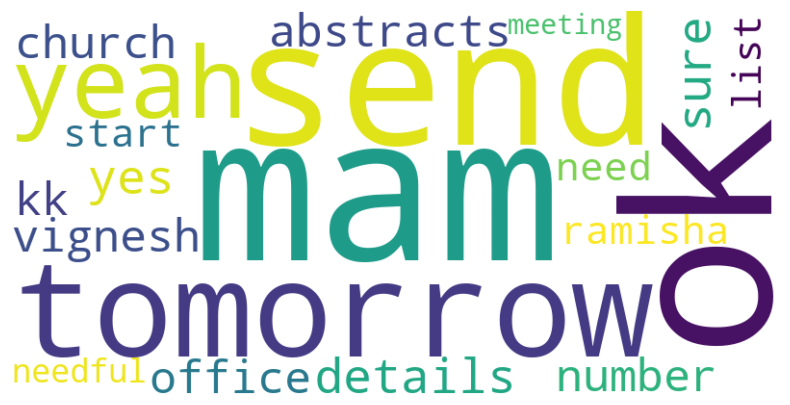

In [24]:
plot_wordcloud_from_top_words(topics)

In [29]:
def nmf_topic_modeling(texts, n_topics=5, n_words=10):
    vectorizer = TfidfVectorizer(stop_words='english')
    X = vectorizer.fit_transform(texts)
    # Applies NMF to the TD-IDF matrix to find n-topics. 
    # Each topic is a group of words that offer appear together
    nmf = NMF(n_components=n_topics, random_state=42)
    nmf.fit(X)
    feature_names = vectorizer.get_feature_names_out()
    print(feature_names)
    #
    #fruits = ["apple", "banana", "cherry"]
    #for idx, fruit in enumerate(fruits):
    #print(idx, fruit)
    #output 0 apple
    #1 banana
    #2 cherry
    #The for loop goes through each topic and prints the most important words that describe that topic.
    for idx, topic in enumerate(nmf.components_):
        top_indices = topic.argsort()[-n_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        print(f"Topic {idx+1}: {', '.join(top_words)}")

In [28]:
nmf_topic_modeling(dataset['Chat'].astype(str).tolist(), n_topics=5, n_words=10)

['10' '30' '7pm' 'abstract' 'abstracts' 'address' 'analysis' 'arun' 'ask'
 'asked' 'attached' 'auditor' 'brother' 'cal' 'calls' 'carry' 'cbe'
 'church' 'com' 'come' 'comfortable' 'committed' 'couldn' 'data' 'dataset'
 'deleted' 'details' 'discuss' 'discussion' 'doubt' 'email' 'evening'
 'file' 'finalization' 'financial' 'finiliaze' 'forward' 'free' 'gmail'
 'good' 'got' 'haven' 'hi' 'hold' 'hot' 'id' 'inform' 'infotest'
 'infoziant' 'involvement' 'issue' 'just' 'kk' 'know' 'lab' 'late' 'let'
 'list' 'location' 'lord' 'ma' 'mabel' 'mam' 'marketing' 'meet' 'meeting'
 'message' 'ml' 'need' 'needful' 'negotiation' 'night' 'number' 'office'
 'ok' 'okay' 'phone' 'plan' 'praise' 'price' 'project' 'projects' 'purum'
 'ramisha' 'ramisharanik' 'rani' 'rates' 'read' 'ready' 'searching' 'send'
 'sent' 'set' 'shall' 'share' 'small' 'soon' 'sorry' 'spoke' 'start'
 'students' 'sure' 'talk' 'tension' 'thank' 'things' 'think' 'titles'
 'today' 'tomorrow' 'updates' 'vcf' 'vignesh' 'visit' 'visited' 'wai